# FLAVORS2 Head-to-Head Benchmark

This notebook compares the current local FLAVORS2 package against recursive feature elimination and permutation-importance feature selection.

The runtime comparison is paired: RFE and permutation are timed first, then FLAVORS2 is run with the same measured fit-time budget for each baseline.
Final holdout scoring is timed and reported separately so selector runtime stays apples to apples.


In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import math
import sys
import time
from typing import Callable, Optional

import numpy as np
import pandas as pd

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.datasets import fetch_openml, load_breast_cancer, load_diabetes, load_iris, load_wine, make_classification, make_regression
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import accuracy_score, r2_score
from sklearn.model_selection import StratifiedKFold, KFold, cross_val_score, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.utils.validation import check_is_fitted

ROOT = Path.cwd()
if not (ROOT / "src" / "flavors2").exists():
    ROOT = Path.cwd().parent

sys.path.insert(0, str(ROOT / "src"))

from flavors2 import FLAVORS2FeatureSelector, __version__ as flavors2_version

print(f"Using FLAVORS2 {flavors2_version} from {ROOT / 'src'}")


Using FLAVORS2 0.1.0 from C:\Users\m0ech\Documents\FLAVORS2\src


In [2]:
def ensure_metric_protocol(metric: Callable) -> Callable:
    def wrapped(X, y, sample_weight=None):
        out = metric(X, y, sample_weight=sample_weight)
        if isinstance(out, (int, float, np.number)):
            return {"score": float(out)}
        if not isinstance(out, dict) or "score" not in out:
            raise TypeError("Metric must return a numeric score or a dict with a 'score' key.")
        out = dict(out)
        out["score"] = float(out["score"])
        return out

    return wrapped


def _sample_metric_rows(X, y, random_state: int, max_rows: int = 5000):
    if len(y) <= max_rows:
        return X, y
    rng = np.random.RandomState(random_state)
    idx = rng.choice(len(y), size=max_rows, replace=False)
    return X[idx], y[idx]


def make_metric(task: str, random_state: int) -> Callable:
    if task == "classification":
        def metric(X, y, sample_weight=None):
            X, y = _sample_metric_rows(X, y, random_state=random_state)
            _, counts = np.unique(y, return_counts=True)
            n_splits = int(min(3, counts.min())) if len(counts) else 0
            model = LogisticRegression(max_iter=2000, solver="liblinear", random_state=random_state)
            if n_splits < 2:
                model.fit(X, y)
                return {"score": float(model.score(X, y)), "model": model}
            cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
            scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")
            model.fit(X, y)
            return {"score": float(np.mean(scores)), "model": model}

        return ensure_metric_protocol(metric)

    def metric(X, y, sample_weight=None):
        X, y = _sample_metric_rows(X, y, random_state=random_state)
        n_splits = min(3, len(y))
        model = Ridge(alpha=1.0, random_state=random_state)
        if n_splits < 2:
            model.fit(X, y)
            return {"score": float(model.score(X, y)), "model": model}
        cv = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
        scores = cross_val_score(model, X, y, cv=cv, scoring="r2")
        model.fit(X, y)
        return {"score": float(np.mean(scores)), "model": model}

    return ensure_metric_protocol(metric)


def holdout_score(task: str, X_train, y_train, X_test, y_test, selected_indices, random_state: int) -> float:
    selected_indices = list(selected_indices)
    if not selected_indices:
        return float("nan")
    if task == "classification":
        model = LogisticRegression(max_iter=2000, solver="liblinear", random_state=random_state)
        model.fit(X_train[:, selected_indices], y_train)
        pred = model.predict(X_test[:, selected_indices])
        return float(accuracy_score(y_test, pred))
    model = Ridge(alpha=1.0, random_state=random_state)
    model.fit(X_train[:, selected_indices], y_train)
    pred = model.predict(X_test[:, selected_indices])
    return float(r2_score(y_test, pred))


In [3]:
def _extract_importances(model) -> Optional[np.ndarray]:
    if model is None:
        return None
    if hasattr(model, "feature_importances_"):
        return np.abs(np.asarray(model.feature_importances_, dtype=float).ravel())
    if hasattr(model, "coef_"):
        coef = np.asarray(model.coef_, dtype=float)
        if coef.ndim == 2:
            return np.mean(np.abs(coef), axis=0)
        return np.abs(coef).ravel()
    return None


class MetricRFEFeatureSelector(BaseEstimator, TransformerMixin):
    def __init__(self, metric: Callable, n_features_to_select: int, step: float | int = 0.2, random_state: int = 42):
        self.metric = metric
        self.n_features_to_select = n_features_to_select
        self.step = step
        self.random_state = random_state

    def fit(self, X, y, sample_weight=None):
        self.n_features_in_ = X.shape[1]
        metric = ensure_metric_protocol(self.metric)
        target = max(1, min(int(self.n_features_to_select), self.n_features_in_))
        subset = list(range(self.n_features_in_))

        while len(subset) > target:
            payload = metric(X[:, subset], y, sample_weight=sample_weight)
            importances = _extract_importances(payload.get("model"))
            if importances is None or len(importances) != len(subset):
                importances = self._permutation_importance_once(metric, X, y, subset, sample_weight)

            if isinstance(self.step, int):
                drop_count = int(self.step)
            else:
                drop_count = int(math.floor(len(subset) * float(self.step)))
            drop_count = max(1, min(drop_count, len(subset) - target))
            drop_positions = set(np.argsort(importances)[:drop_count])
            subset = [feature for pos, feature in enumerate(subset) if pos not in drop_positions]

        self.selected_indices_ = subset
        return self

    def _permutation_importance_once(self, metric, X, y, subset, sample_weight):
        rng = np.random.RandomState(self.random_state)
        base_score = float(metric(X[:, subset], y, sample_weight=sample_weight)["score"])
        importances = np.zeros(len(subset), dtype=float)
        for pos in range(len(subset)):
            X_perm = X[:, subset].copy()
            rng.shuffle(X_perm[:, pos])
            importances[pos] = base_score - float(metric(X_perm, y, sample_weight=sample_weight)["score"])
        return importances

    def transform(self, X):
        check_is_fitted(self, "selected_indices_")
        return X[:, self.selected_indices_]


class PermutationFeatureSelector(BaseEstimator, TransformerMixin):
    def __init__(self, metric: Callable, n_features_to_select: int, n_repeats: int = 3, random_state: int = 42):
        self.metric = metric
        self.n_features_to_select = n_features_to_select
        self.n_repeats = n_repeats
        self.random_state = random_state

    def fit(self, X, y, sample_weight=None):
        self.n_features_in_ = X.shape[1]
        metric = ensure_metric_protocol(self.metric)
        rng = np.random.RandomState(self.random_state)
        base_score = float(metric(X, y, sample_weight=sample_weight)["score"])
        importances = np.zeros(self.n_features_in_, dtype=float)

        for feature in range(self.n_features_in_):
            drops = []
            for _ in range(self.n_repeats):
                X_perm = X.copy()
                rng.shuffle(X_perm[:, feature])
                drops.append(base_score - float(metric(X_perm, y, sample_weight=sample_weight)["score"]))
            importances[feature] = float(np.mean(drops))

        target = max(1, min(int(self.n_features_to_select), self.n_features_in_))
        self.importances_ = importances
        self.selected_indices_ = np.argsort(-importances)[:target].tolist()
        return self

    def transform(self, X):
        check_is_fitted(self, "selected_indices_")
        return X[:, self.selected_indices_]


In [4]:
OPENML_DATASETS = [
    {"name": "MiniBooNE", "version": 1, "task": "classification", "size": "130k"},
    {"name": "pol", "version": 1, "task": "regression", "size": "15k"},
    {"name": "puma32H", "version": 1, "task": "regression", "size": "8k"},
    {"name": "nomao", "version": 1, "task": "classification", "size": "34k"},
    {"name": "optdigits", "version": 1, "task": "classification", "size": "5.6k"},
    {"name": "satimage", "version": 1, "task": "classification", "size": "6.4k"},
    {"name": "texture", "version": 1, "task": "classification", "size": "5.5k"},
    {"name": "mfeat-fourier", "version": 1, "task": "classification", "size": "2k"},
    {"name": "mfeat-karhunen", "version": 1, "task": "classification", "size": "2k"},
    {"name": "mfeat-zernike", "version": 1, "task": "classification", "size": "2k"},
    {"name": "splice", "version": 1, "task": "classification", "size": "3.2k"},
    {"name": "waveform-5000", "version": 1, "task": "classification", "size": "5k"},
    {"name": "SpeedDating", "version": 1, "task": "classification", "size": "8.4k"},
    {"name": "ozone-level-8hr", "version": 1, "task": "classification", "size": "2.5k"},
    {"name": "spambase", "version": 1, "task": "classification", "size": "4.6k"},
    {"name": "qsar-biodeg", "version": 1, "task": "classification", "size": "1.1k"},
    {"name": "kr-vs-kp", "version": 1, "task": "classification", "size": "3.2k"},
    {"name": "pc3", "version": 1, "task": "classification", "size": "1.6k"},
    {"name": "pc4", "version": 1, "task": "classification", "size": "1.5k"},
    {"name": "hill-valley", "version": 1, "task": "classification", "size": "1.2k"},
    {"name": "PhishingWebsites", "version": 1, "task": "classification", "size": "11k"},
]


def builtin_datasets(task: str) -> list[tuple[str, str, np.ndarray, np.ndarray]]:
    datasets = []
    if task in ("classification", "both"):
        X, y = make_classification(
            n_samples=700,
            n_features=50,
            n_informative=12,
            n_redundant=12,
            random_state=42,
            shuffle=True,
        )
        datasets.append(("synthetic_classification_50", "classification", X, y))
        classification_loaders = [
            ("breast_cancer", load_breast_cancer),
            ("wine", load_wine),
            ("iris", load_iris),
        ]
        for name, loader in classification_loaders:
            data = loader()
            datasets.append((name, "classification", data.data, data.target))
    if task in ("regression", "both"):
        X, y = make_regression(
            n_samples=700,
            n_features=50,
            n_informative=12,
            noise=10.0,
            random_state=42,
        )
        datasets.append(("synthetic_regression_50", "regression", X, y))
        data = load_diabetes()
        datasets.append(("diabetes", "regression", data.data, data.target))
    return datasets


def _encode_openml_frame(data, target, dataset_task: str, max_features: int):
    X_df = pd.DataFrame(data).copy()
    y = pd.Series(target).copy()

    missing_target = y.isna()
    if missing_target.any():
        X_df = X_df.loc[~missing_target]
        y = y.loc[~missing_target]

    converted = pd.DataFrame(index=X_df.index)
    for column in X_df.columns:
        series = X_df[column]
        if pd.api.types.is_numeric_dtype(series):
            converted[column] = pd.to_numeric(series, errors="coerce")
        else:
            categories = pd.Categorical(series)
            codes = categories.codes.astype(float)
            codes[codes < 0] = np.nan
            converted[column] = codes

    converted = converted.dropna(axis=1, how="all")
    if converted.shape[1] == 0:
        raise ValueError("no usable features after encoding")
    if converted.shape[1] > max_features:
        raise ValueError(f"{converted.shape[1]} features exceeds max_features={max_features}")

    X = converted.to_numpy(dtype=float)
    if dataset_task == "classification":
        y_encoded, _ = pd.factorize(y, sort=True)
        if len(np.unique(y_encoded)) < 2:
            raise ValueError("classification target has fewer than two classes")
        return X, y_encoded.astype(int)

    y_numeric = pd.to_numeric(y, errors="coerce")
    keep = ~y_numeric.isna().to_numpy()
    if keep.sum() < 30:
        raise ValueError("too few numeric regression targets")
    return X[keep], y_numeric.to_numpy(dtype=float)[keep]


def _cap_openml_samples(X, y, dataset_task: str, max_samples: int, random_state: int):
    if X.shape[0] <= max_samples:
        return X, y
    if dataset_task == "classification" and np.min(np.unique(y, return_counts=True)[1]) >= 2:
        _, X_sample, _, y_sample = train_test_split(
            X,
            y,
            test_size=max_samples,
            random_state=random_state,
            stratify=y,
        )
        return X_sample, y_sample
    rng = np.random.RandomState(random_state)
    idx = rng.choice(X.shape[0], size=max_samples, replace=False)
    return X[idx], y[idx]


def openml_datasets(task: str, min_features: int, max_features: int, min_samples: int, max_samples: int, max_per_task: int | None, max_datasets: int | None, random_state: int) -> list[tuple[str, str, np.ndarray, np.ndarray]]:
    selected = []
    counts = {"classification": 0, "regression": 0}

    for spec in OPENML_DATASETS:
        if max_datasets is not None and len(selected) >= max_datasets:
            break
        dataset_task = spec["task"]
        if task not in ("both", dataset_task):
            continue
        if max_per_task is not None and counts[dataset_task] >= max_per_task:
            continue

        label = f"openml_{spec['name']}_{spec['size']}"
        try:
            data_home = ROOT / "benchmarks" / "openml_cache"
            data_home.mkdir(parents=True, exist_ok=True)
            bunch = fetch_openml(
                name=spec["name"],
                version=spec.get("version", 1),
                as_frame=True,
                parser="auto",
                data_home=data_home,
            )
            X, y = _encode_openml_frame(bunch.data, bunch.target, dataset_task, max_features=max_features)
            if X.shape[1] < min_features:
                print(f"Skipping {label}: {X.shape[1]} features is below min_features={min_features}")
                continue
            if X.shape[0] < min_samples:
                print(f"Skipping {label}: {X.shape[0]} samples is below min_samples={min_samples}")
                continue
            X, y = _cap_openml_samples(X, y, dataset_task, max_samples=max_samples, random_state=random_state)
            selected.append((label, dataset_task, X, y))
            counts[dataset_task] += 1
            print(f"Selected {label}: shape={X.shape}, task={dataset_task}")
        except Exception as exc:
            print(f"Skipping {label}: {exc}")

    return selected


def pmlb_datasets(task: str, min_features: int, max_per_task: int | None) -> list[tuple[str, str, np.ndarray, np.ndarray]]:
    try:
        from pmlb import classification_dataset_names, fetch_data, regression_dataset_names
    except Exception as exc:
        raise RuntimeError("Install pmlb to use source='pmlb'.") from exc

    output = []
    task_names = []
    if task in ("classification", "both"):
        task_names.extend(("classification", name) for name in classification_dataset_names)
    if task in ("regression", "both"):
        task_names.extend(("regression", name) for name in regression_dataset_names)

    counts = {"classification": 0, "regression": 0}
    for dataset_task, name in sorted(task_names, key=lambda pair: pair[1].lower()):
        if max_per_task is not None and counts[dataset_task] >= max_per_task:
            continue
        try:
            df = fetch_data(name, return_X_y=False)
            if "target" not in df.columns or df.shape[1] - 1 < min_features:
                continue
            X = df.drop(columns=["target"]).to_numpy(dtype=float)
            y = df["target"].to_numpy()
            output.append((name, dataset_task, X, y))
            counts[dataset_task] += 1
        except Exception as exc:
            print(f"Skipping {name}: {exc}")
    return output


def load_benchmark_datasets(source: str, task: str, min_features: int, max_features: int, min_samples: int, max_samples: int, max_per_task: int | None, max_datasets: int | None, random_state: int):
    if source == "openml":
        return openml_datasets(
            task,
            min_features=min_features,
            max_features=max_features,
            min_samples=min_samples,
            max_samples=max_samples,
            max_per_task=max_per_task,
            max_datasets=max_datasets,
            random_state=random_state,
        )
    if source == "builtin":
        datasets = builtin_datasets(task)
        if max_per_task is not None:
            per_task_counts = {"classification": 0, "regression": 0}
            kept = []
            for item in datasets:
                feature_count = item[2].shape[1]
                sample_count = item[2].shape[0]
                if per_task_counts[item[1]] < max_per_task and min_features <= feature_count <= max_features and min_samples <= sample_count <= max_samples:
                    kept.append(item)
                    per_task_counts[item[1]] += 1
            return kept
        return [item for item in datasets if min_features <= item[2].shape[1] <= max_features and min_samples <= item[2].shape[0] <= max_samples]
    if source == "pmlb":
        return pmlb_datasets(task, min_features=min_features, max_per_task=max_per_task)
    raise ValueError("source must be 'openml', 'builtin', or 'pmlb'")


In [5]:
def prepare_split(X, y, task: str, random_state: int, fast: bool):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y)

    stratify = y if task == "classification" and np.min(np.unique(y, return_counts=True)[1]) >= 2 else None
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.3,
        random_state=random_state,
        stratify=stratify,
    )
    prep = make_pipeline(SimpleImputer(strategy="median"), StandardScaler())
    X_train = prep.fit_transform(X_train)
    X_test = prep.transform(X_test)
    return X_train, X_test, y_train, y_test


def timed_fit(selector, X, y):
    start = time.perf_counter()
    selector.fit(X, y)
    elapsed = time.perf_counter() - start
    return elapsed, list(selector.selected_indices_)


def score_with_timing(task, X_train, y_train, X_test, y_test, selected_indices, random_state):
    start = time.perf_counter()
    score = holdout_score(task, X_train, y_train, X_test, y_test, selected_indices, random_state)
    elapsed = time.perf_counter() - start
    return score, elapsed


def run_one_dataset(name: str, task: str, X, y, *, target_fraction: float, permutation_repeats: int, random_state: int, fast: bool):
    X_train, X_test, y_train, y_test = prepare_split(X, y, task, random_state, fast)
    metric = make_metric(task, random_state)
    target_k = max(1, min(X_train.shape[1], math.ceil(X_train.shape[1] * target_fraction)))
    rows = []

    baselines = [
        ("RFE", MetricRFEFeatureSelector(metric, n_features_to_select=target_k, step=0.2, random_state=random_state)),
        ("Permutation", PermutationFeatureSelector(metric, n_features_to_select=target_k, n_repeats=permutation_repeats, random_state=random_state)),
    ]

    baseline_timings = []
    for selector_name, selector in baselines:
        fit_time, selected = timed_fit(selector, X_train, y_train)
        score, score_time = score_with_timing(task, X_train, y_train, X_test, y_test, selected, random_state)
        baseline_timings.append((selector_name, fit_time))
        rows.append({
            "dataset": name,
            "task": task,
            "selector": selector_name,
            "paired_baseline": selector_name,
            "budget_sec": np.nan,
            "fit_time_sec": fit_time,
            "score_time_sec": score_time,
            "total_time_sec": fit_time + score_time,
            "target_k": target_k,
            "k": len(selected),
            "score": score,
            "n_samples_train": X_train.shape[0],
            "n_samples_test": X_test.shape[0],
            "n_features": X_train.shape[1],
        })

    for baseline_name, budget_sec in baseline_timings:
        budget_sec = max(0.05, float(budget_sec))
        selector = FLAVORS2FeatureSelector(
            metrics=[metric],
            budget=budget_sec,
            random_state=random_state,
            n_jobs=1,
        )
        fit_time, selected = timed_fit(selector, X_train, y_train)
        score, score_time = score_with_timing(task, X_train, y_train, X_test, y_test, selected, random_state)
        rows.append({
            "dataset": name,
            "task": task,
            "selector": f"FLAVORS2@{baseline_name}_time",
            "paired_baseline": baseline_name,
            "budget_sec": budget_sec,
            "fit_time_sec": fit_time,
            "score_time_sec": score_time,
            "total_time_sec": fit_time + score_time,
            "target_k": target_k,
            "k": len(selected),
            "score": score,
            "n_samples_train": X_train.shape[0],
            "n_samples_test": X_test.shape[0],
            "n_features": X_train.shape[1],
        })

    return rows


def run_benchmark(*, source: str, task: str, min_features: int, max_features: int, min_samples: int, max_samples: int, max_per_task: int | None, max_datasets: int | None, target_fraction: float, permutation_repeats: int, random_state: int, fast: bool) -> pd.DataFrame:
    datasets = load_benchmark_datasets(source, task, min_features, max_features, min_samples, max_samples, max_per_task, max_datasets, random_state)
    print(f"Loaded {len(datasets)} dataset(s) from {source}.")
    rows = []
    for name, dataset_task, X, y in datasets:
        print(f"Running {name} ({dataset_task}) with shape {X.shape}.")
        try:
            rows.extend(run_one_dataset(
                name,
                dataset_task,
                X,
                y,
                target_fraction=target_fraction,
                permutation_repeats=permutation_repeats,
                random_state=random_state,
                fast=fast,
            ))
        except Exception as exc:
            print(f"Skipping {name}: {exc}")
    return pd.DataFrame(rows)


In [6]:
@dataclass
class Args:
    source: str = "openml"
    task: str = "both"
    min_features: int = 30
    max_features: int = 150
    min_samples: int = 1000
    max_samples: int = 20000
    max_per_task: Optional[int] = None
    max_datasets: Optional[int] = 20
    target_fraction: float = 0.2
    permutation_repeats: int = 1
    random_state: int = 42
    fast: bool = False
    output_csv: Path = ROOT / "benchmarks" / "h2h_benchmark_summary.csv"


args = Args()

results = run_benchmark(
    source=args.source,
    task=args.task,
    min_features=args.min_features,
    max_features=args.max_features,
    min_samples=args.min_samples,
    max_samples=args.max_samples,
    max_per_task=args.max_per_task,
    max_datasets=args.max_datasets,
    target_fraction=args.target_fraction,
    permutation_repeats=args.permutation_repeats,
    random_state=args.random_state,
    fast=args.fast,
)

if results.empty:
    raise RuntimeError("No benchmark results were produced.")

baseline_times = (
    results[results["selector"] == results["paired_baseline"]]
    .set_index(["dataset", "task", "paired_baseline"])["fit_time_sec"]
)
results["paired_baseline_fit_time_sec"] = [
    baseline_times.get((row.dataset, row.task, row.paired_baseline), np.nan)
    for row in results.itertuples(index=False)
]
results["fit_time_ratio_to_pair"] = results["fit_time_sec"] / results["paired_baseline_fit_time_sec"]

args.output_csv.parent.mkdir(parents=True, exist_ok=True)
results.to_csv(args.output_csv, index=False)
print(f"Wrote {args.output_csv}")
results

Selected openml_MiniBooNE_130k: shape=(20000, 50), task=classification
Selected openml_pol_15k: shape=(15000, 48), task=regression
Selected openml_puma32H_8k: shape=(8192, 32), task=regression


C:\Users\m0ech\AppData\Local\Temp\ipykernel_16128\4070822078.py:73: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  converted[column] = pd.to_numeric(series, errors="coerce")
C:\Users\m0ech\AppData\Local\Temp\ipykernel_16128\4070822078.py:73: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  converted[column] = pd.to_numeric(series, errors="coerce")
C:\Users\m0ech\AppData\Local\Temp\ipykernel_16128\4070822078.py:73: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, wh

Selected openml_nomao_34k: shape=(20000, 118), task=classification
Selected openml_optdigits_5.6k: shape=(5620, 64), task=classification
Selected openml_satimage_6.4k: shape=(6430, 36), task=classification
Selected openml_texture_5.5k: shape=(5500, 40), task=classification
Selected openml_mfeat-fourier_2k: shape=(2000, 76), task=classification


Selected openml_mfeat-karhunen_2k: shape=(2000, 64), task=classification
Selected openml_mfeat-zernike_2k: shape=(2000, 47), task=classification
Selected openml_splice_3.2k: shape=(3190, 60), task=classification
Selected openml_waveform-5000_5k: shape=(5000, 40), task=classification


C:\Users\m0ech\AppData\Local\Temp\ipykernel_16128\4070822078.py:78: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  converted[column] = codes
C:\Users\m0ech\AppData\Local\Temp\ipykernel_16128\4070822078.py:78: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  converted[column] = codes
C:\Users\m0ech\AppData\Local\Temp\ipykernel_16128\4070822078.py:78: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once us

...

Initializing FLAVORS2 state...
Calculating fast feature priors.
Starting feature selection search with budget: 0.073744 seconds...
Search finished.
Best subset found: [3, 7, 9, 31, 35, 36] with score marker: inf
Number of feats that were never evaluated: 37
Initializing FLAVORS2 state...
Calculating fast feature priors.
Starting feature selection search with budget: 0.584513 seconds...


Search finished.
Best subset found: [3, 7, 9, 31, 35, 36] with score marker: inf
Number of feats that were never evaluated: 37
Running openml_hill-valley_1.2k (classification) with shape (1212, 100).


Initializing FLAVORS2 state...
Calculating fast feature priors.
Starting feature selection search with budget: 0.081159 seconds...
Search finished.
Best subset found: [40, 43, 74, 75, 77, 78, 79, 80, 81, 84] with score marker: inf
Number of feats that were never evaluated: 100
Initializing FLAVORS2 state...
Calculating fast feature priors.
Starting feature selection search with budget: 2.060697 seconds...


Performing probabilistic restart... best_global_score=0.654491
Search finished.
Best subset found: [0, 2, 3, 4, 5, 6, 7, 8, 9, 11, 12, 14, 15, 19, 22, 25, 26, 27, 28, 29, 31, 32, 35, 36, 40, 41, 42, 43, 44, 46, 47, 48, 49, 52, 53, 55, 56, 57, 58, 61, 62, 63, 65, 66, 67, 68, 71, 72, 73, 74, 76, 77, 78, 80, 81, 82, 83, 86, 87, 88, 89, 90, 92, 93, 94, 95, 96, 97, 98, 99] with score marker: -0.654499661679573
Number of feats that were never evaluated: 0
Wrote C:\Users\m0ech\Documents\FLAVORS2\benchmarks\h2h_benchmark_summary.csv


,dataset,task,selector,paired_baseline,budget_sec,fit_time_sec,score_time_sec,total_time_sec,target_k,k,score,n_samples_train,n_samples_test,n_features,paired_baseline_fit_time_sec,fit_time_ratio_to_pair
0,openml_MiniBooNE_130k,classification,RFE,RFE,NaN,0.395317,0.018430,0.413746,10,10,0.825833,14000,6000,50,0.395317,1.000000
1,openml_MiniBooNE_130k,classification,Permutation,Permutation,NaN,4.558739,0.029893,4.588632,10,10,0.858833,14000,6000,50,4.558739,1.000000
2,openml_MiniBooNE_130k,classification,FLAVORS2@RFE_time,RFE,0.395317,0.362879,0.026950,0.389829,10,7,0.851167,14000,6000,50,0.395317,0.917945
3,openml_MiniBooNE_130k,classification,FLAVORS2@Permutation_time,Permutation,4.558739,4.467073,0.082300,4.549373,10,27,0.861667,14000,6000,50,4.558739,0.979892
4,openml_pol_15k,regression,RFE,RFE,NaN,0.104278,0.002257,0.106535,10,10,0.465522,10500,4500,48,0.104278,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,openml_pc4_1.5k,classification,FLAVORS2@Permutation_time,Permutation,0.586284,0.537860,0.013287,0.551146,8,6,0.897260,1020,438,37,0.586284,0.917405
76,openml_hill-valley_1.2k,classification,RFE,RFE,NaN,0.086518,0.001270,0.087787,20,20,0.607143,848,364,100,0.086518,1.000000
77,openml_hill-valley_1.2k,classification,Permutation,Permutation,NaN,2.064982,0.001627,2.066609,20,20,0.585165,848,364,100,2.064982,1.000000
78,openml_hill-valley_1.2k,classification,FLAVORS2@RFE_time,RFE,0.086518,0.048514,0.012501,0.061016,20,10,0.480769,848,364,100,0.086518,0.560745


In [7]:
summary = (
    results
    .groupby(["dataset", "task", "selector", "paired_baseline"], dropna=False, as_index=False)
    .agg(
        score=("score", "mean"),
        fit_time_sec=("fit_time_sec", "mean"),
        total_time_sec=("total_time_sec", "mean"),
        fit_time_ratio_to_pair=("fit_time_ratio_to_pair", "mean"),
        k=("k", "mean"),
        target_k=("target_k", "mean"),
    )
)
summary["score"] = summary["score"].round(4)
summary["fit_time_sec"] = summary["fit_time_sec"].round(3)
summary["total_time_sec"] = summary["total_time_sec"].round(3)
summary["fit_time_ratio_to_pair"] = summary["fit_time_ratio_to_pair"].round(2)
summary["k"] = summary["k"].round(1)
summary


,dataset,task,selector,paired_baseline,score,fit_time_sec,total_time_sec,fit_time_ratio_to_pair,k,target_k
0,openml_MiniBooNE_130k,classification,FLAVORS2@Permutation_time,Permutation,0.8617,4.467,4.549,0.98,27.0,10.0
1,openml_MiniBooNE_130k,classification,FLAVORS2@RFE_time,RFE,0.8512,0.363,0.390,0.92,7.0,10.0
2,openml_MiniBooNE_130k,classification,Permutation,Permutation,0.8588,4.559,4.589,1.00,10.0,10.0
3,openml_MiniBooNE_130k,classification,RFE,RFE,0.8258,0.395,0.414,1.00,10.0,10.0
4,openml_SpeedDating_8.4k,classification,FLAVORS2@Permutation_time,Permutation,0.8500,27.745,27.793,0.92,58.0,24.0
...,...,...,...,...,...,...,...,...,...,...
75,openml_texture_5.5k,classification,RFE,RFE,0.9588,1.899,1.930,1.00,8.0,8.0
76,openml_waveform-5000_5k,classification,FLAVORS2@Permutation_time,Permutation,0.8727,2.765,2.790,0.97,27.0,8.0
77,openml_waveform-5000_5k,classification,FLAVORS2@RFE_time,RFE,0.7447,0.294,0.311,0.90,6.0,8.0
78,openml_waveform-5000_5k,classification,Permutation,Permutation,0.8293,2.847,2.854,1.00,8.0,8.0


In [8]:
paired = results.pivot_table(
    index=["dataset", "task", "paired_baseline"],
    columns="selector",
    values=["score", "fit_time_sec"],
    aggfunc="mean",
)
paired


fit_time_sec  \
selector                                                   FLAVORS2@Permutation_time   
dataset                     task           paired_baseline                             
openml_MiniBooNE_130k       classification Permutation                      4.467073   
                                           RFE                                   NaN   
openml_SpeedDating_8.4k     classification Permutation                     27.745264   
                                           RFE                                   NaN   
openml_hill-valley_1.2k     classification Permutation                      1.906240   
                                           RFE                                   NaN   
openml_kr-vs-kp_3.2k        classification Permutation                      0.961368   
                                           RFE                                   NaN   
openml_mfeat-fourier_2k     classification Permutation                     24.772946   
                                           RFE                                   NaN   
openml_mfeat-karhunen_2k    classification Permutation                     14.563283   
                                           RFE                                   NaN   
openml_mfeat-zernike_2k     classification Permutation                     10.262244   
                                           RFE                                   NaN   
openml_nomao_34k            classification Permutation                     40.206120   
                                           RFE                                   NaN   
openml_optdigits_5.6k       classification Permutation                     52.670883   
                                           RFE                                   NaN   
openml_ozone-level-8hr_2.5k classification Permutation                      3.499466   
                                           RFE                                   NaN   
openml_pc3_1.6k             classification Permutation                      0.607996   
                                           RFE                                   NaN   
openml_pc4_1.5k             classification Permutation                      0.537860   
                                           RFE                                   NaN   
openml_pol_15k              regression     Permutation                      0.764575   
                                           RFE                                   NaN   
openml_puma32H_8k           regression     Permutation                      0.401867   
                                           RFE                                   NaN   
openml_qsar-biodeg_1.1k     classification Permutation                      0.607740   
                                           RFE                                   NaN   
openml_satimage_6.4k        classification Permutation                      8.811060   
                                           RFE                                   NaN   
openml_spambase_4.6k        classification Permutation                      5.049084   
                                           RFE                                   NaN   
openml_splice_3.2k          classification Permutation                      3.780359   
                                           RFE                                   NaN   
openml_texture_5.5k         classification Permutation                     17.023447   
                                           RFE                                   NaN   
openml_waveform-5000_5k     classification Permutation                      2.764565   
                                           RFE                                   NaN   

                                                                              \
selector                                                   FLAVORS2@RFE_time   
dataset                     task           paired_baseline                     
openml_MiniBooNE_130k       classification Perm

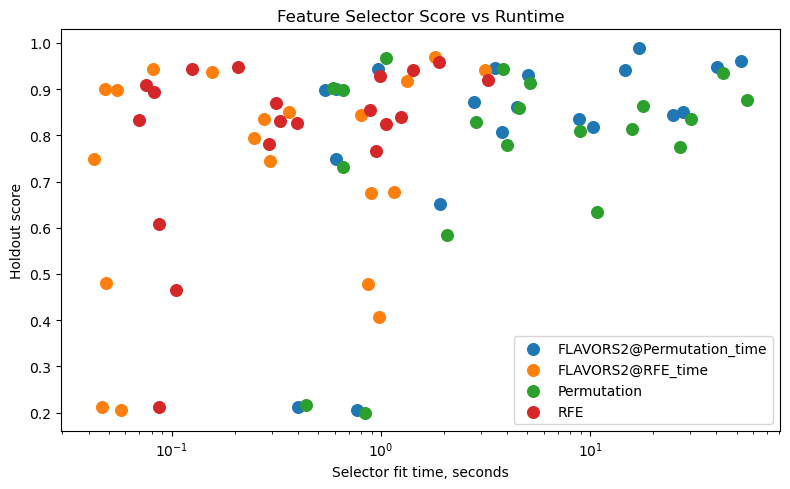

In [9]:
import matplotlib.pyplot as plt

plot_df = results.copy()
fig, ax = plt.subplots(figsize=(8, 5))
for selector, group in plot_df.groupby("selector"):
    ax.scatter(group["fit_time_sec"], group["score"], label=selector, s=70)
ax.set_xscale("log")
ax.set_xlabel("Selector fit time, seconds")
ax.set_ylabel("Holdout score")
ax.set_title("Feature Selector Score vs Runtime")
ax.legend()
fig.tight_layout()
plt.show()
